# Frequency Filtering Experiments

**Filters:** Butterworth Low-Pass (denoise) and High-Pass (edge detail).

**Method:** corrupted images are preprocessed (resize 224 + minmax), then each
filter's parameters are swept and scored against the **ground-truth** image with
**PSNR** and **SSIM**. The best parameters per filter are chosen by *average rank*
(rank by PSNR + rank by SSIM, lowest wins) and applied to all 2500 images.

Run `python -m filtering_frequency.optimize_frequency` first to generate the outputs
and report files this notebook reads. This notebook only visualises results.

In [1]:
import sys, json
sys.path.insert(0, '..')
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from filtering_frequency.fft_transform import FFTTransform
from filtering_frequency.butterworth import ButterworthFilter

PROJECT_ROOT = Path('..').resolve()
FREQ     = PROJECT_ROOT / 'output' / '03_frequency_filtering'
NORM     = PROJECT_ROOT / 'output' / '01_preprocessing' / 'normalized'
GT       = PROJECT_ROOT / 'output' / '01_preprocessing' / 'groundtruth_normalized'
FIG      = FREQ / 'figures'; FIG.mkdir(parents=True, exist_ok=True)

assert (FREQ / 'best_params.json').exists(), \
    'Run: python -m filtering_frequency.optimize_frequency'

best      = json.loads((FREQ / 'best_params.json').read_text())
lpf_sweep = pd.read_csv(FREQ / 'butterworth_lpf_sweep.csv')
lpf_m     = pd.read_csv(FREQ / 'butterworth_lpf_best_metrics.csv').set_index('image_name')
labels    = pd.read_csv(PROJECT_ROOT / 'data' / 'balanced_2500.csv').set_index('Image Index')['Finding Labels']

def load(d, name):
    return cv2.imread(str(d / name), cv2.IMREAD_GRAYSCALE)

best

{'sweep_size': 200,
 'preprocess': {'size': 224, 'norm': 'minmax'},
 'selection': 'average rank of PSNR and SSIM (lower is better)',
 'butterworth_lpf': {'params': {'cutoff': 30.0, 'order': 2},
  'sweep_psnr': 24.55700999705299,
  'sweep_ssim': 0.8571455731069964,
  'fullset_psnr': 24.513464372458852,
  'fullset_ssim': 0.8538076326405523,
  'output_dir': 'output\\03_frequency_filtering\\butterworth_lpf'},
 'butterworth_hpf': {'params': {'cutoff': 30.0, 'order': 2},
  'scored': False,
  'note': 'produced for report only; not scored vs groundtruth',
  'output_dir': 'output\\03_frequency_filtering\\butterworth_hpf'}}

## 1. Best parameters and full-set scores

In [2]:
lpf_p = best['butterworth_lpf']['params']
summary = pd.DataFrame([
    {'filter': 'Butterworth LPF', **lpf_p,
     'mean_PSNR': best['butterworth_lpf']['fullset_psnr'],
     'mean_SSIM': best['butterworth_lpf']['fullset_ssim'],
     'scored': True},
    {'filter': 'Butterworth HPF', **best['butterworth_hpf']['params'],
     'mean_PSNR': None, 'mean_SSIM': None,
     'scored': False},
])
summary.round(4)

,filter,cutoff,order,mean_PSNR,mean_SSIM,scored
0,Butterworth LPF,30.0,2,24.5135,0.8538,True
1,Butterworth HPF,30.0,2,NaN,NaN,False


## 2. FFT spectrum analysis
Magnitude spectrum, phase spectrum, and IFFT reconstruction of a sample image.

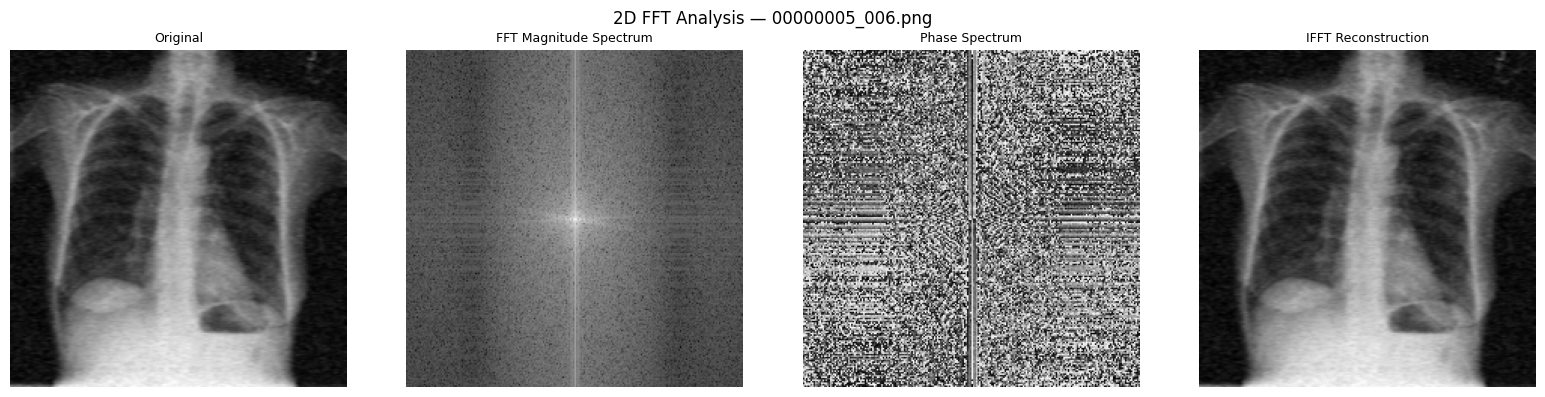

In [3]:
name   = sorted(p.name for p in (FREQ / 'butterworth_lpf').glob('*.png'))[0]
sample = load(NORM, name)

fft_shifted   = FFTTransform.compute_fft(sample)
spectrum      = FFTTransform.get_magnitude_spectrum(fft_shifted)
phase         = FFTTransform.get_phase_spectrum(fft_shifted)
reconstructed = FFTTransform.compute_ifft(fft_shifted)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, img) in zip(axes, [
    ('Original', sample),
    ('FFT Magnitude Spectrum', spectrum),
    ('Phase Spectrum', phase),
    ('IFFT Reconstruction', reconstructed),
]):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=9)
    ax.axis('off')
plt.suptitle(f'2D FFT Analysis \u2014 {name}', fontsize=12)
plt.tight_layout()
plt.savefig(FIG / 'fft_analysis.png', dpi=130, bbox_inches='tight')
plt.show()

## 3. Qualitative comparison
Ground truth vs corrupted input vs each filter's best result (PSNR/SSIM vs ground truth).

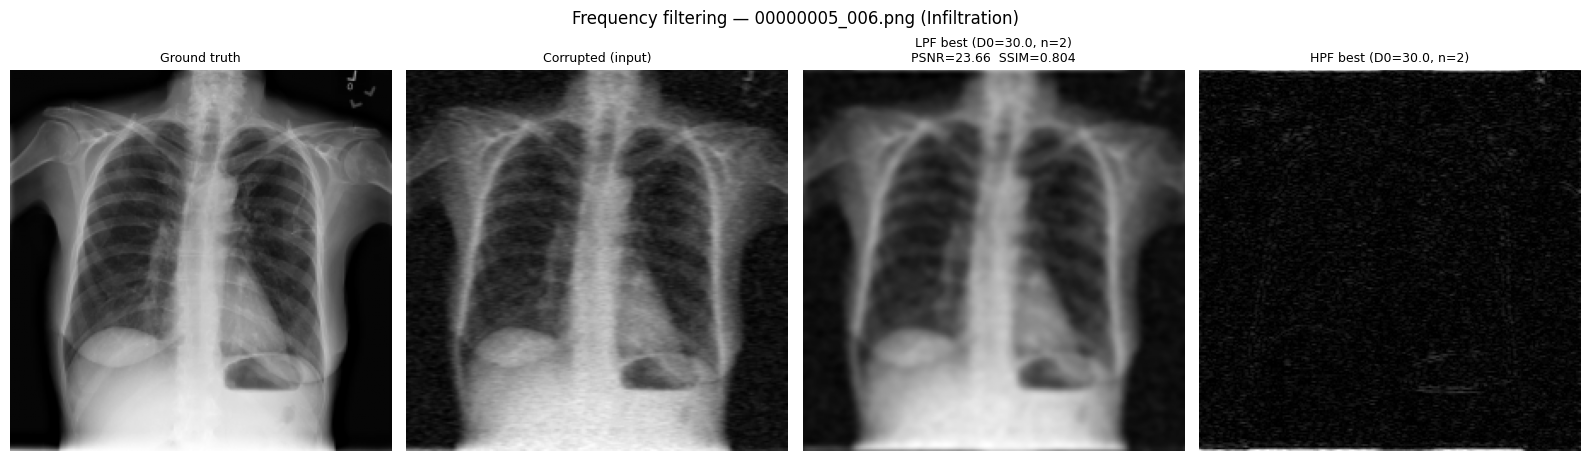

In [4]:
lp      = best['butterworth_lpf']['params']
gt_img  = load(GT, name)
inp_img = load(NORM, name)
lpf_img = load(FREQ / 'butterworth_lpf', name)
hpf_img = load(FREQ / 'butterworth_hpf', name)

panels = [
    ('Ground truth', gt_img, None),
    ('Corrupted (input)', inp_img, None),
    (f"LPF best (D0={lp['cutoff']}, n={lp['order']})", lpf_img, lpf_m.loc[name]),
    (f"HPF best (D0={lp['cutoff']}, n={lp['order']})", hpf_img, None),
]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (title, img, m) in zip(axes, panels):
    ax.imshow(img, cmap='gray')
    if m is not None:
        title += f'\nPSNR={m.psnr:.2f}  SSIM={m.ssim:.3f}'
    ax.set_title(title, fontsize=9); ax.axis('off')
plt.suptitle(f'Frequency filtering \u2014 {name} ({labels.get(name, "?")})', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG / 'qualitative_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Visual parameter grids (single sample)
Qualitative look at how cutoff and order change the image.

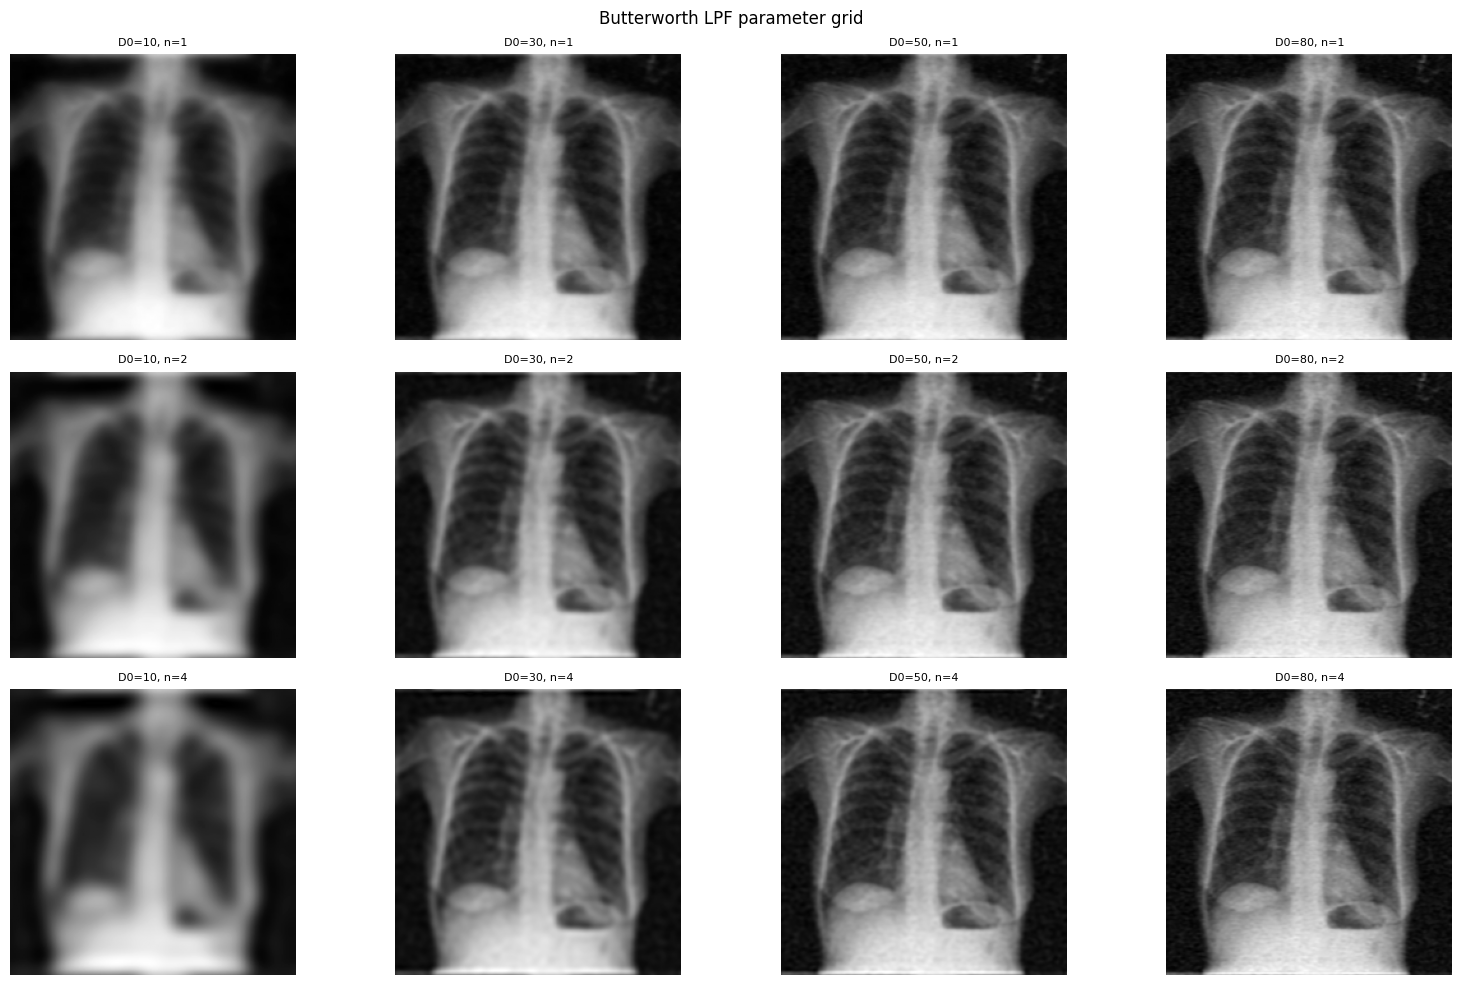

In [5]:
cutoffs = [10, 30, 50, 80]
orders  = [1, 2, 4]

fig, axes = plt.subplots(len(orders), len(cutoffs), figsize=(16, 10))
for r, n in enumerate(orders):
    for c, d0 in enumerate(cutoffs):
        result = ButterworthFilter.apply_with_params(sample, d0, n, 'lpf')
        axes[r, c].imshow(result, cmap='gray')
        axes[r, c].set_title(f'D0={d0}, n={n}', fontsize=8)
        axes[r, c].axis('off')
plt.suptitle('Butterworth LPF parameter grid', fontsize=12)
plt.tight_layout()
plt.savefig(FIG / 'lpf_param_grid.png', dpi=130)
plt.show()

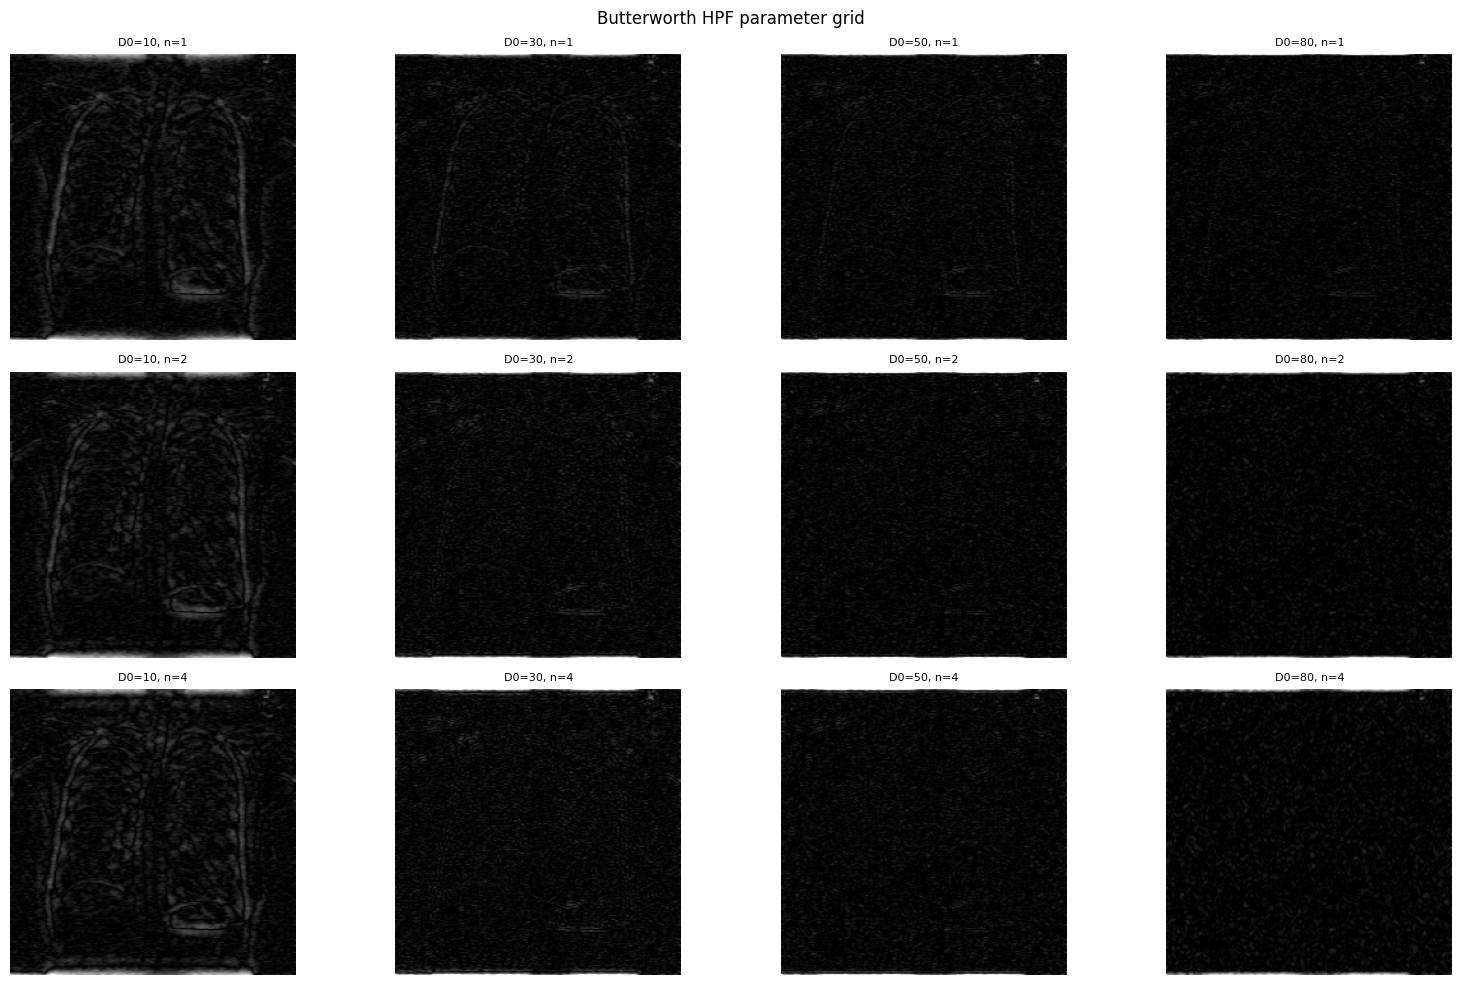

In [6]:
fig, axes = plt.subplots(len(orders), len(cutoffs), figsize=(16, 10))
for r, n in enumerate(orders):
    for c, d0 in enumerate(cutoffs):
        result = ButterworthFilter.apply_with_params(sample, d0, n, 'hpf')
        axes[r, c].imshow(result, cmap='gray')
        axes[r, c].set_title(f'D0={d0}, n={n}', fontsize=8)
        axes[r, c].axis('off')
plt.suptitle('Butterworth HPF parameter grid', fontsize=12)
plt.tight_layout()
plt.savefig(FIG / 'hpf_param_grid.png', dpi=130)
plt.show()

## 5. PSNR / SSIM vs parameters (quantitative)
Scores averaged over the sweep subset. Red circle = chosen best.
HPF is not scored (high-pass vs clean image is not meaningful).

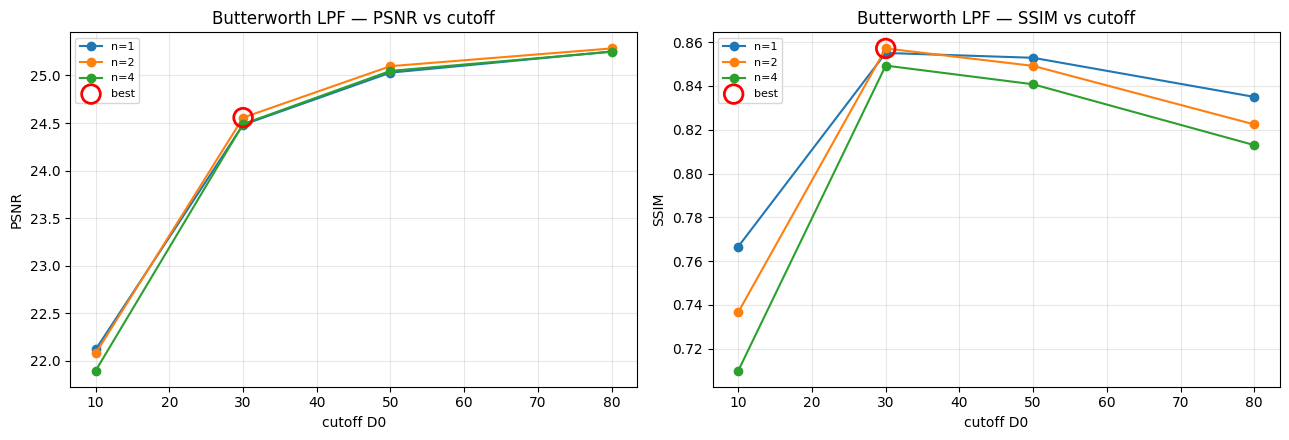

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for metric, ax in zip(['psnr', 'ssim'], axes):
    for order, sub in lpf_sweep.groupby('order'):
        sub = sub.sort_values('cutoff')
        ax.plot(sub.cutoff, sub[metric], marker='o', label=f'n={order}')
    bp = best['butterworth_lpf']['params']
    by = lpf_sweep[(lpf_sweep.cutoff == bp['cutoff']) & (lpf_sweep.order == bp['order'])][metric].iloc[0]
    ax.scatter([bp['cutoff']], [by], s=180, facecolors='none', edgecolors='red', linewidths=2, zorder=5, label='best')
    ax.set_xlabel('cutoff D0'); ax.set_ylabel(metric.upper())
    ax.set_title(f'Butterworth LPF \u2014 {metric.upper()} vs cutoff'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / 'lpf_sweep_curves.png', dpi=130, bbox_inches='tight')
plt.show()

## 6. Metric distribution over all 2500 images
Per-image PSNR/SSIM of the best Butterworth LPF result. Dashed line = mean.
HPF not shown — not scored vs ground truth.

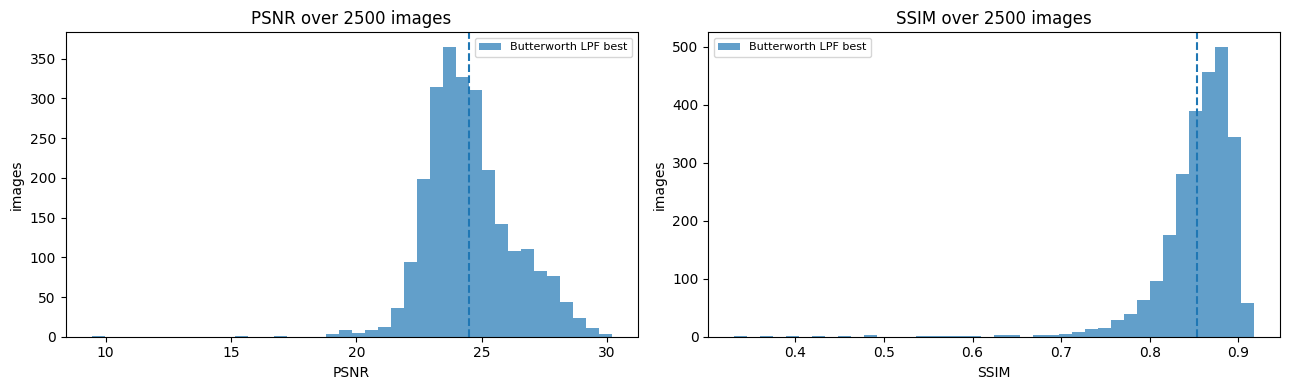

Butterworth LPF: PSNR=24.51±1.74  SSIM=0.8538±0.0461


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for metric, ax in zip(['psnr', 'ssim'], axes):
    ax.hist(lpf_m[metric], bins=40, alpha=0.7, label='Butterworth LPF best')
    ax.axvline(lpf_m[metric].mean(), color='C0', ls='--')
    ax.set_xlabel(metric.upper()); ax.set_ylabel('images')
    ax.set_title(f'{metric.upper()} over 2500 images'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / 'metric_distributions.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Butterworth LPF: PSNR={lpf_m.psnr.mean():.2f}\u00b1{lpf_m.psnr.std():.2f}  SSIM={lpf_m.ssim.mean():.4f}\u00b1{lpf_m.ssim.std():.4f}")